In [40]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
 12  Title        888 non-null    object 
 13  AgeGroup     889 non-null    object 
 14  Sex_encoded  889 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 111.1+ KB


In [41]:
#Matplotlib: figure, axes, subplots — build a reusable plot function
def plot_chart(ax,plot_type,title,xlabel,ylabel,*args,**kwargs):
  getattr(ax,plot_type)(*args,**kwargs)
  ax.set_title(title)
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  plt.tight_layout()
  plt.show()

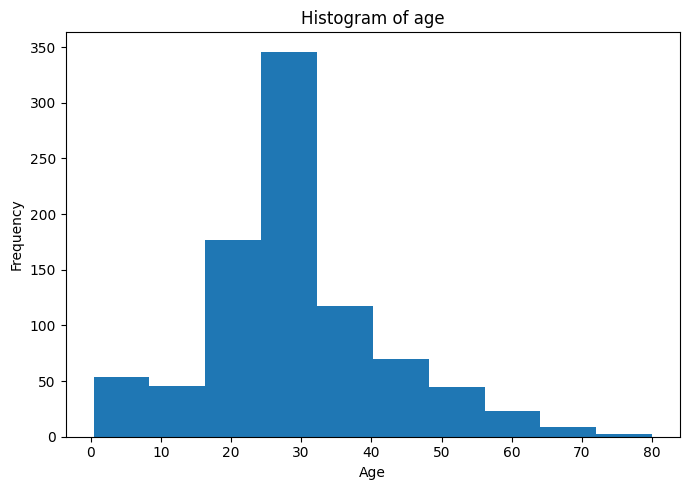

In [42]:
#day 4 recap
#Create figure and axes, plot a histogram of Age
#Call your plot_chart function for a bar chart

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(x=df['Age'])
ax.set_title("Histogram of age")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()



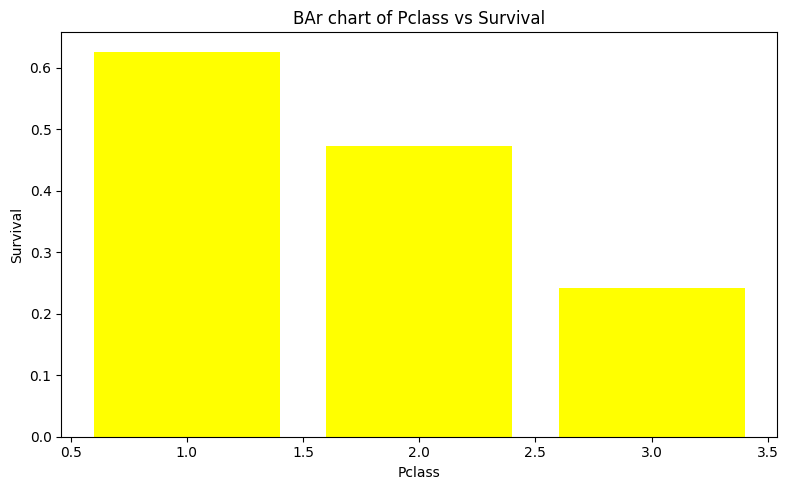

In [43]:
#bar
fig,ax = plt.subplots(figsize=(8,5))
survived_Pclass = df.groupby('Pclass')['Survived'].mean()
plot_chart(ax,'bar','BAr chart of Pclass vs Survival','Pclass', 'Survival',x=survived_Pclass.index,height=survived_Pclass.values,color="yellow")

# Day -5
1. •	Seaborn: heatmap, pairplot, boxplot, violin, countplot, FacetGrid
2. •	Plot correlation heatmap — find the top 5 features correlated with survival
3. •	Pairplot coloured by survival — visually spot separability


In [44]:
#corelation matrix
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_encoded
PassengerId,1.000000,-0.005028,-0.035330,0.031319,-0.057686,-0.001657,0.012703,-0.043136
Survived,-0.005028,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290,0.541585
Pclass,-0.035330,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193,-0.127741
Age,0.031319,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707,-0.086506
SibSp,-0.057686,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887,0.116348
Parch,-0.001657,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532,0.247508
Fare,0.012703,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000,0.179958
Sex_encoded,-0.043136,0.541585,-0.127741,-0.086506,0.116348,0.247508,0.179958,1.000000


In [45]:
 #top 5 features correlated with Survived
df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)

,Survived
Survived,1.000000
Sex_encoded,0.541585
Fare,0.255290
Parch,0.083151
PassengerId,-0.005028
SibSp,-0.034040
Age,-0.069822
Pclass,-0.335549


<Axes: >

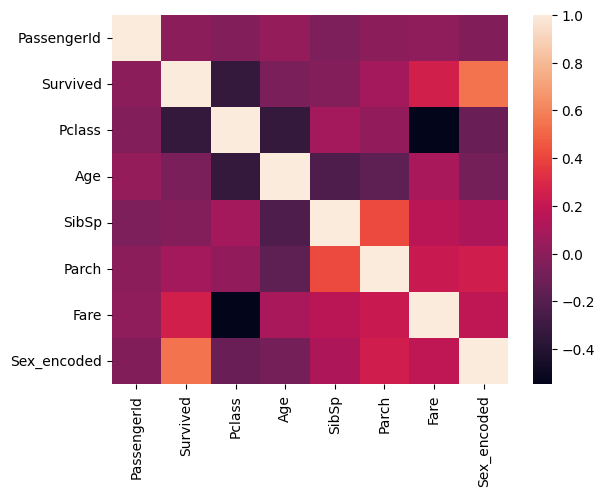

In [46]:
#1. Seaborn: heatmap
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr)

<Axes: >

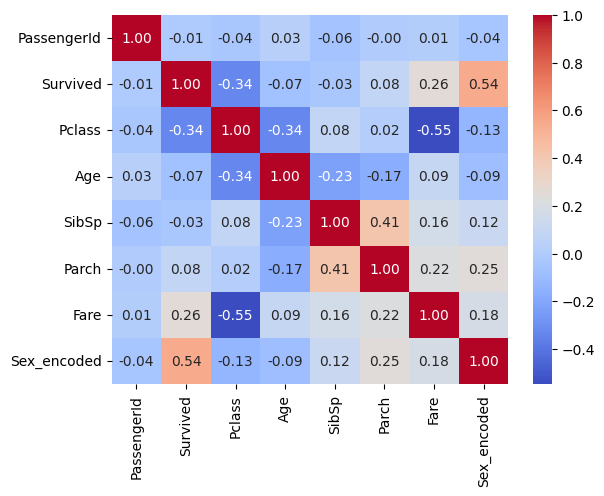

In [47]:
#annotation = True -> values respective to each variable
#fmt -> format of annot -> .2f - 2 decimals float
#cmap -> colorvalue

sns.heatmap(corr, annot=True,fmt='.2f',cmap='coolwarm')

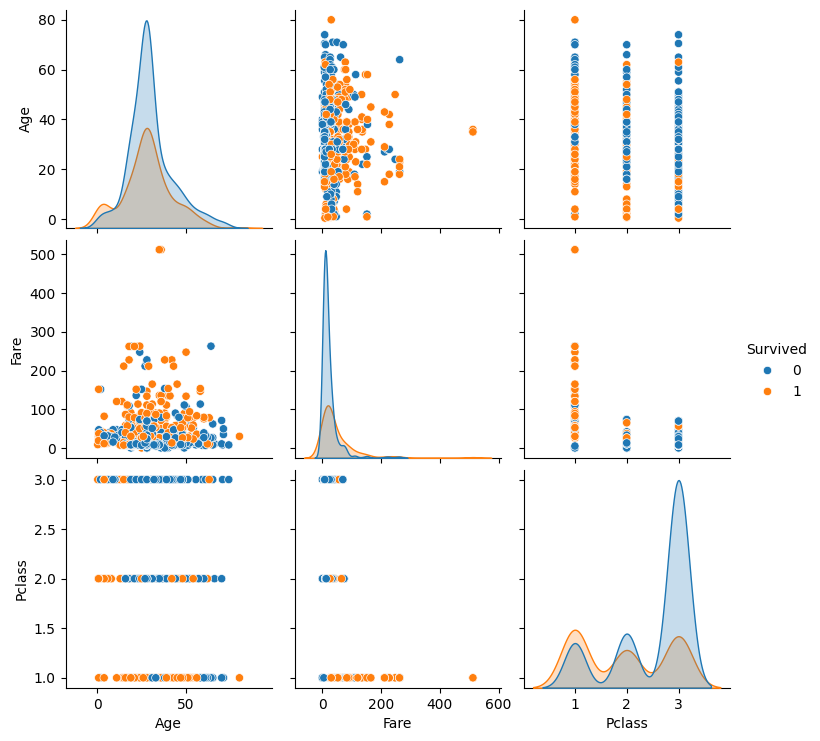

In [48]:
# 1. Seaborn- pairplot
sns.pairplot(df[['Survived','Age','Fare','Pclass']],hue="Survived")
plt.show()


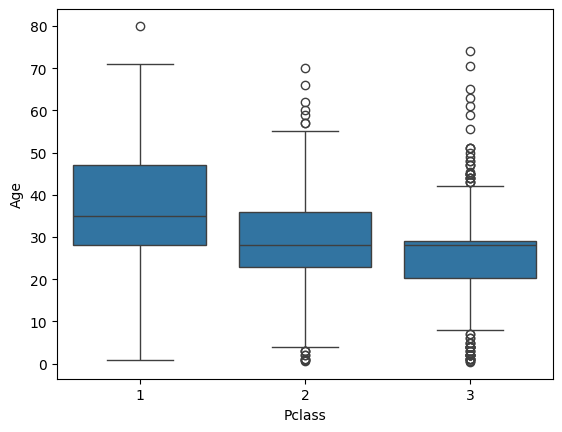

In [49]:
#1.seaborn-boxplot

#shows the distribution of quantitative data in a way that facilitates
  #comparisons between variables or across levels of a categorical variable.

#Age by Pclass
sns.boxplot(data=df,x='Pclass',y='Age')
plt.show()

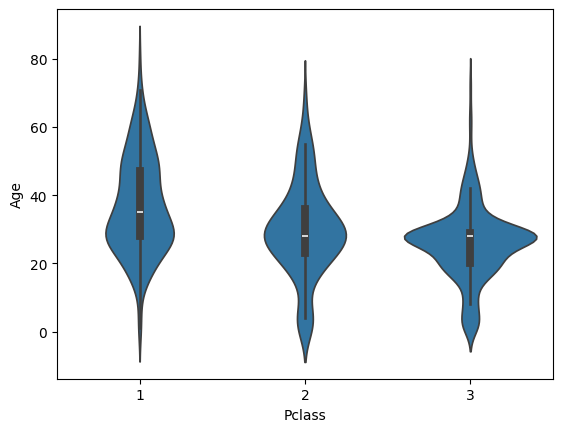

In [50]:
#1.seaborn - violinplot

sns.violinplot(data=df, x='Pclass', y='Age')
plt.show()

# the width of the violin at each point shows the density of data there.
  #Wider = more passengers at that age.

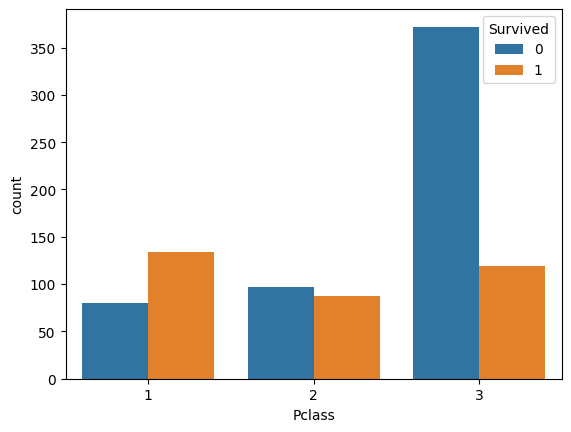

In [51]:
#1. seaborn-countplot
  #Pclass coloured by survival

#bar chart showed survival rate, countplot shows actual counts of survivors vs non-survivors side by side.
sns.countplot(data=df, x='Pclass', hue="Survived")
plt.show()

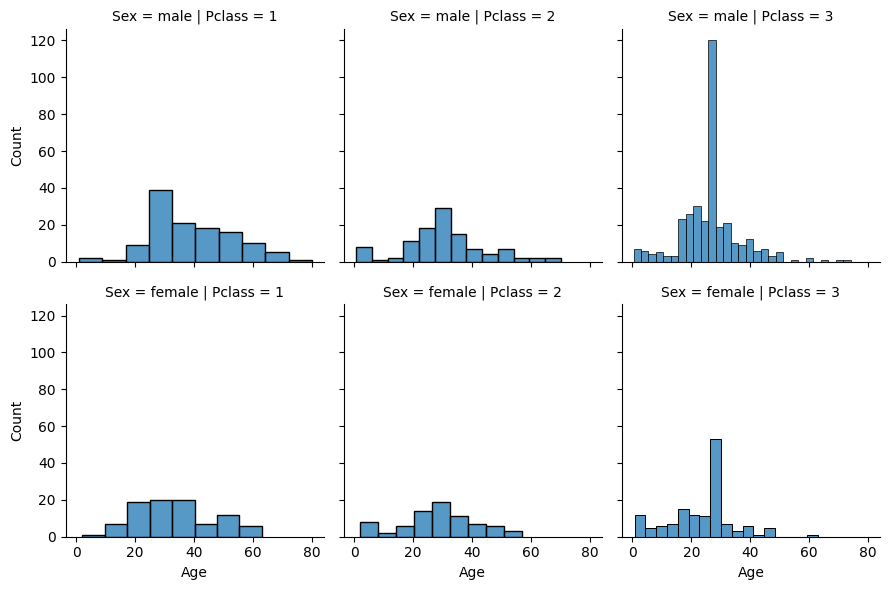

In [52]:
#1.Seaborn - Facetgrid

g = sns.FacetGrid(df, col='Pclass', row='Sex')
g.map(sns.histplot, 'Age')

### Pairplot → fixed structure, always plots every variable against every other variable. You can't change the plot type per cell easily.

### FacetGrid → you control the grid structure (what splits the rows/columns) AND you choose what plot goes in each cell with .map(). More flexible.

- So:

1. Want to explore all variable relationships quickly → pairplot
2. Want to compare one specific plot across subgroups → FacetGrid

In [54]:
#2.Plot correlation heatmap — find the top 5 features correlated with survival
df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)

,Survived
Survived,1.000000
Sex_encoded,0.541585
Fare,0.255290
Parch,0.083151
PassengerId,-0.005028
SibSp,-0.034040
Age,-0.069822
Pclass,-0.335549


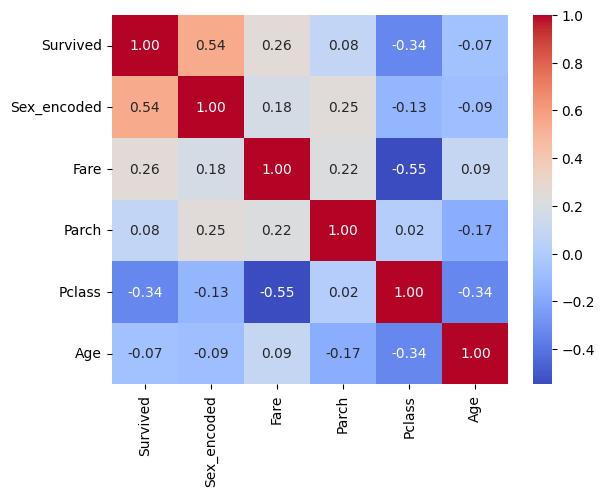

In [57]:
#top 5
top_features = ['Survived','Sex_encoded','Fare','Parch','Pclass','Age']
corr_top5 = df[top_features].corr()
sns.heatmap(corr_top5,annot=True, fmt='.2f',cmap='coolwarm')
plt.show()

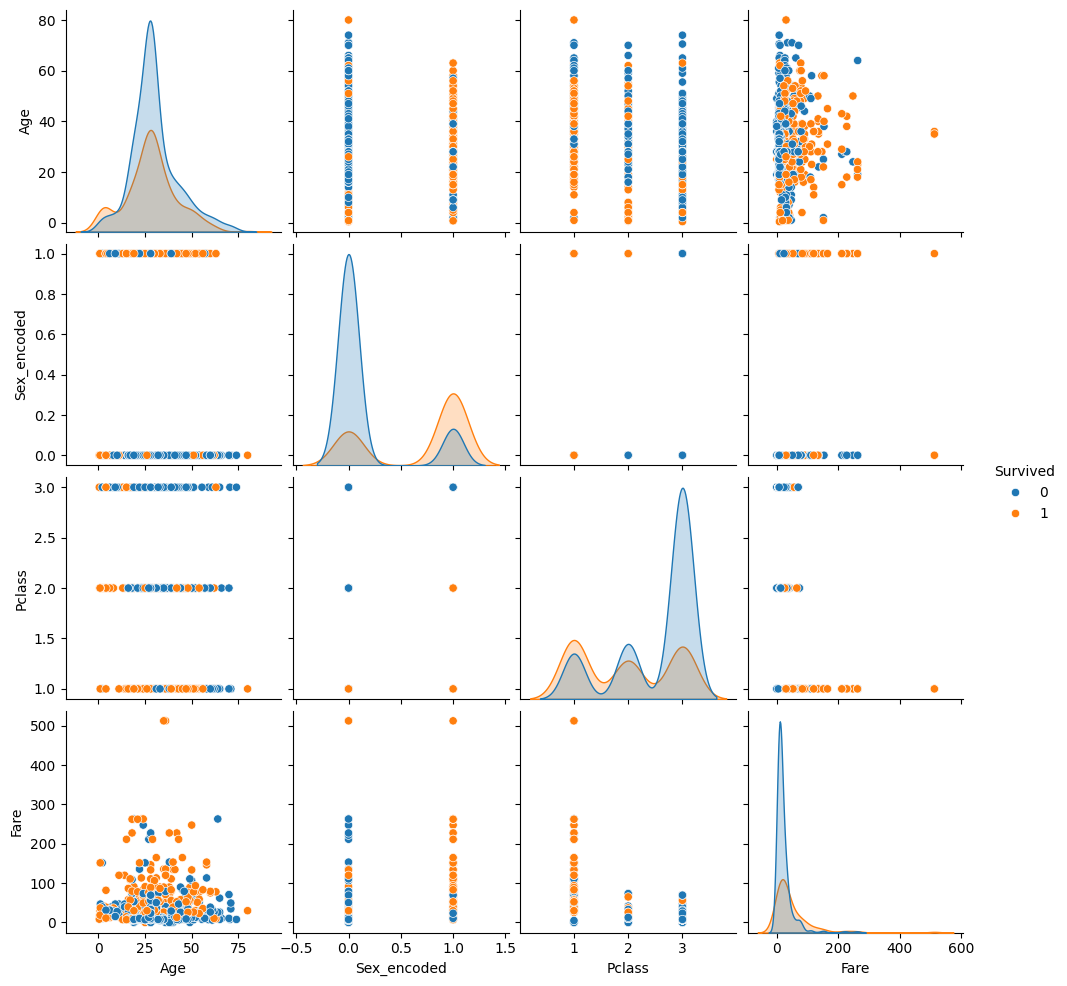

In [60]:
#3.Pairplot coloured by survival — visually spot separability
sns.pairplot(df[['Survived','Age','Sex_encoded','Pclass','Fare']],hue='Survived')
plt.show()